## Import libraries

In [ ]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
pwd


'/content'

In [ ]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/ML_Project/ML-Group-Project/house-price-prediction-ml/data/raw/train.csv")

In [ ]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.shape

(1460, 81)

In [ ]:
df .dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [ ]:
df["LotFrontage"].isnull().sum()

np.int64(259)

In [ ]:
# Separate features and target

X = df.drop("SalePrice", axis=1)
Y = df["SalePrice"]

In [ ]:
y.head()

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000


### Preprocess the data

In [ ]:
# Handle missing values

# Fill numerical missing values with median
#num_cols = X.select_dtypes(include=[np.number]).columns
#X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# Fill categorical missing values with mode
cat_cols = X.select_dtypes(exclude=[np.number]).columns
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

In [ ]:
##### Count missing values in numerical columns ##### Only columns that actually have missing values

import numpy as np

num_cols = X.select_dtypes(include=[np.number]).columns

# X[num_cols].isnull().sum()

missing_num = X[num_cols].isnull().sum()
# missing_num[missing_num > 0]


missing_percent = (X[num_cols].isnull().sum() / len(X)) * 100
missing_percent[missing_percent > 0]

,0


In [ ]:
import numpy as np

cat_cols = X.select_dtypes(exclude=[np.number]).columns # Select categorical columns

#X[cat_cols].isnull().sum() # Count missing values in categorical columns

#missing_cat = X[cat_cols].isnull().sum() # Show only columns that HAVE missing values
#missing_cat[missing_cat > 0]

missing_cat_percent = (X[cat_cols].isnull().sum() / len(X)) * 100
missing_cat_percent[missing_cat_percent > 0]

,0


In [ ]:
# LotFrontage = width of the property facing the street (in feet) -(How wide your land is along the road)
#🤔 Why missing values?
  # Not all properties have clearly recorded frontage
  #Irregular plots (corner lots, curved roads)
  # Data not collected
#💡 Important insight:
  # It’s a useful feature, but often missing
  # You can fill it using median (good approach 👍)
# Fill numerical missing values with median
X["LotFrontage"] = X["LotFrontage"].fillna(X["LotFrontage"].median())

# MasVnrArea = area of masonry veneer (in square feet) Masonry veneer means: Decorative brick or stone layer on the outside of a house
#🤔 Why missing values?
  # Some houses don’t have masonry veneer at all
#👉 Missing here often means:
  # “No veneer” → should be treated as 0

X["MasVnrArea"] = X["MasVnrArea"].fillna(0)

# GarageYrBlt = year the garage was built
#🤔 Why missing values?
  #Some houses do not have garages
#👉 Missing = “No garage”
# Fill with median

X["GarageYrBlt"] = X["GarageYrBlt"].fillna(X["GarageYrBlt"].median())

## Convert categorical columns into numbers

In [ ]:
X = pd.get_dummies(X, drop_first=True)

# 6: Split the data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
# Why random_state=42?
  # So your results stay reproducible.

# 7: Scale the features
For SVR, scaling is required.

In [ ]:
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# 8: Train the SVR model

In [ ]:
# Start with a RBF SVR:
svr_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)

SVR(C=100)

# 9: Predict

In [ ]:
y_pred = svr_model.predict(X_test_scaled)

# 10: Evaluate the model

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 57083.63798131392
MSE: 7505553523.628858
RMSE: 86634.59772878764
R2 Score: 0.021481835205897082


# 12: visualization

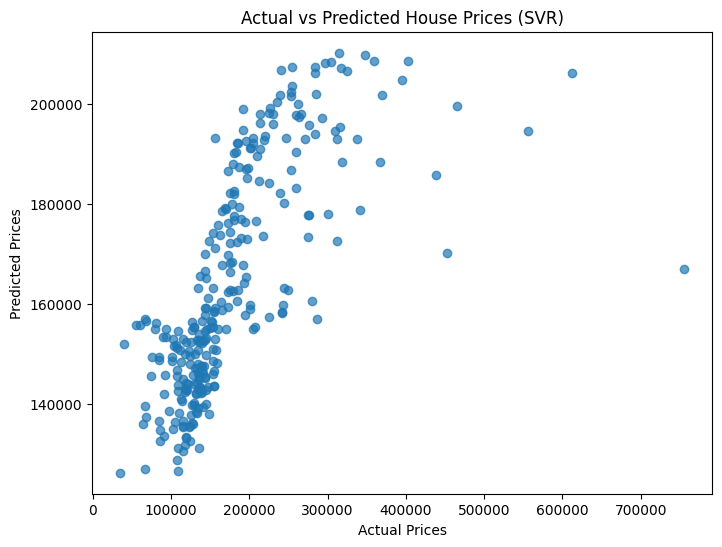

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices (SVR)")
plt.show()

# 13: Improve the model with tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [50, 100, 1000],
    'gamma': ['scale', 0.1, 0.01],
    'epsilon': [0.1, 0.2, 0.5],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVR(), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
best_svr = grid.best_estimator_

Best Parameters: {'C': 1000, 'epsilon': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
y_pred = best_svr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Tuned MAE:", mae)
print("Tuned MSE:", mse)
print("Tuned RMSE:", rmse)
print("Tuned R2 Score:", r2)

Tuned MAE: 43004.88466409234
Tuned MSE: 5657304752.289938
Tuned RMSE: 75215.05668607807
Tuned R2 Score: 0.26244274370117127
